In [94]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 16.3 MB/s eta 0:00:07
   --- ------------------------------------ 8.4/101.7 MB 31.4 MB/s eta 0:00:03
   ----- ---------------------------------- 13.4/101.7 MB 29.5 MB/s eta 0:00:03
   -------- ------------------------------- 22.8/101.7 MB 31.7 MB/s eta 0:00:03
   ------------ --------------------------- 30.9/101.7 MB 33.3 MB/s eta 0:00:03
   --------------- ------------------------ 38.5/101.7 MB 33.8 MB/s eta 0:00:02
   ------------------ --------------------- 46.1/101.7 MB 34.4 MB/s eta 0:00:02
   -------------------- ------------------- 52.4/101.7 MB 34.7 MB/s eta 0:00:02
   -------------------- ------------------- 52.4/101.7 MB 34.7 MB/s eta 0:00:02
   -------------------- ------------------- 52.4/101.7 MB 34.7 MB/s eta 0:00:02
   -------------------- ------------------- 52.4/101.7 MB 34.7 MB/s eta 0:00:02
   -------------------- ------------------- 52.4/10

In [108]:
import os
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso

from xgboost import XGBRegressor

from itertools import product
import random
import time

# Preparation

In [60]:
DATA_PATH = "merge_outputs/all_features_all_timerange.csv"
OUTPUT_DIR = "modeling_outputs"
MODEL_OUTPUT_DIR = "modeling_outputs/saved_models"

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (95088, 60)


,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,...,cooling_degree,heating_degree,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,...,5.2,0.0,552.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,...,4.3,0.0,510.76,38210.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,...,3.4,0.0,470.89,35171.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,...,3.0,0.0,453.69,33243.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,...,2.9,0.0,449.44,31955.0,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
info_df = pd.DataFrame({
    "column": df.columns,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "dtype": df.dtypes.astype(str).values
})

info_df

,column,non_null_count,null_count,dtype
0,timestamp_utc,95088,0,object
1,Region,95088,0,object
2,data_date,95088,0,object
3,region_demand_mw,94867,221,float64
4,region_demand_forecast_mw,95088,0,float64
5,num_ba,95088,0,int64
6,num_rows,95088,0,int64
7,num_available_ba,95088,0,int64
8,num_missing_ba,95088,0,int64
9,year,95088,0,int64


In [62]:
info_df.to_csv(f"{OUTPUT_DIR}/dataset_info_before_modeling.csv", index=False)

## fixing data type

In [63]:
df_model = df.copy()

# Datetime columns
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)
df_model["data_date"] = pd.to_datetime(df_model["data_date"])

if "timestamp_local" in df_model.columns:
    df_model["timestamp_local"] = df_model["timestamp_utc"].dt.tz_convert("America/Los_Angeles")

if "local_date" in df_model.columns:
    df_model["local_date"] = pd.to_datetime(df_model["local_date"])

# Binary columns for modeling
binary_cols = [
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period",
]

for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({
            "No": 0,
            "Yes": 1,
            0: 0,
            1: 1,
            False: 0,
            True: 1
        }).astype("int8")

df_model = df_model.sort_values("timestamp_utc").reset_index(drop=True)

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95088 entries, 0 to 95087
Data columns (total 60 columns):
 #   Column                     Non-Null Count  Dtype                              
---  ------                     --------------  -----                              
 0   timestamp_utc              95088 non-null  datetime64[ns, UTC]                
 1   Region                     95088 non-null  object                             
 2   data_date                  95088 non-null  datetime64[ns]                     
 3   region_demand_mw           94867 non-null  float64                            
 4   region_demand_forecast_mw  95088 non-null  float64                            
 5   num_ba                     95088 non-null  int64                              
 6   num_rows                   95088 non-null  int64                              
 7   num_available_ba           95088 non-null  int64                              
 8   num_missing_ba             95088 non-null  int

## Define Time-Based Split Boundaries

In [64]:
warmup_start_date = pd.Timestamp("2015-07-01")
modeling_start_date = pd.Timestamp("2017-07-01")

train_end_date = pd.Timestamp("2024-01-01")
valid_end_date = pd.Timestamp("2025-01-01")
test_end_date = pd.Timestamp("2026-05-07")

In [65]:
warmup_df = df_model[
    (df_model["data_date"] >= warmup_start_date) &
    (df_model["data_date"] < modeling_start_date)
].copy()

train_df = df_model[
    (df_model["data_date"] >= modeling_start_date) &
    (df_model["data_date"] < train_end_date)
].copy()

valid_df = df_model[
    (df_model["data_date"] >= train_end_date) &
    (df_model["data_date"] < valid_end_date)
].copy()

test_df = df_model[
    (df_model["data_date"] >= valid_end_date) &
    (df_model["data_date"] < test_end_date)
].copy()

print("Warm-up:", warmup_df.shape, warmup_df["timestamp_utc"].min(), "to", warmup_df["timestamp_utc"].max())
print("Train:", train_df.shape, train_df["timestamp_utc"].min(), "to", train_df["timestamp_utc"].max())
print("Validation:", valid_df.shape, valid_df["timestamp_utc"].min(), "to", valid_df["timestamp_utc"].max())
print("Test:", test_df.shape, test_df["timestamp_utc"].min(), "to", test_df["timestamp_utc"].max())

Warm-up: (17544, 60) 2015-07-01 08:00:00+00:00 to 2017-07-01 07:00:00+00:00
Train: (57001, 60) 2017-07-01 08:00:00+00:00 to 2024-01-01 08:00:00+00:00
Validation: (8784, 60) 2024-01-01 09:00:00+00:00 to 2025-01-01 08:00:00+00:00
Test: (11759, 60) 2025-01-01 09:00:00+00:00 to 2026-05-06 07:00:00+00:00


## Check Target Missing Values by Split

In [66]:
target_check = pd.DataFrame([
    {
        "split": "warmup",
        "rows": len(warmup_df),
        "missing_region_demand_mw": warmup_df["region_demand_mw"].isna().sum(),
        "missing_target_region_demand_mw": warmup_df["target_region_demand_mw"].isna().sum(),
    },
    {
        "split": "train",
        "rows": len(train_df),
        "missing_region_demand_mw": train_df["region_demand_mw"].isna().sum(),
        "missing_target_region_demand_mw": train_df["target_region_demand_mw"].isna().sum(),
    },
    {
        "split": "validation",
        "rows": len(valid_df),
        "missing_region_demand_mw": valid_df["region_demand_mw"].isna().sum(),
        "missing_target_region_demand_mw": valid_df["target_region_demand_mw"].isna().sum(),
    },
    {
        "split": "test",
        "rows": len(test_df),
        "missing_region_demand_mw": test_df["region_demand_mw"].isna().sum(),
        "missing_target_region_demand_mw": test_df["target_region_demand_mw"].isna().sum(),
    },
])

target_check

,split,rows,missing_region_demand_mw,missing_target_region_demand_mw
0,warmup,17544,0,0
1,train,57001,221,0
2,validation,8784,0,0
3,test,11759,0,0


## Define Feature Columns

In [67]:
feature_cols = [
    # Weather
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "cooling_degree",
    "heating_degree",
    "temp_squared",

    # Calendar and seasonality
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",

    # Holiday
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period",

    # Historical demand
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_std_24h",
    "rolling_std_168h",
]

feature_cols = [col for col in feature_cols if col in df_model.columns]

print("Number of features:", len(feature_cols))
feature_cols

Number of features: 27


['temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'precipitation',
 'cooling_degree',
 'heating_degree',
 'temp_squared',
 'hour_sin',
 'hour_cos',
 'day_of_week_sin',
 'day_of_week_cos',
 'month_sin',
 'month_cos',
 'day_of_year_sin',
 'day_of_year_cos',
 'is_weekend',
 'is_holiday',
 'is_day_before_holiday',
 'is_day_after_holiday',
 'is_holiday_period',
 'lag_1h',
 'lag_24h',
 'lag_168h',
 'rolling_mean_24h',
 'rolling_mean_168h',
 'rolling_std_24h',
 'rolling_std_168h']

## Create Model-Ready Train, Validation, and Test Sets

In [68]:
train_model_df = train_df.dropna(
    subset=feature_cols + ["target_region_demand_mw"]
).copy()

valid_model_df = valid_df.dropna(
    subset=feature_cols + ["region_demand_mw"]
).copy()

test_model_df = test_df.dropna(
    subset=feature_cols + ["region_demand_mw"]
).copy()

X_train = train_model_df[feature_cols]
y_train = train_model_df["target_region_demand_mw"]

X_valid = valid_model_df[feature_cols]
y_valid = valid_model_df["region_demand_mw"]

X_test = test_model_df[feature_cols]
y_test = test_model_df["region_demand_mw"]

print("Train model data:", X_train.shape, y_train.shape)
print("Validation model data:", X_valid.shape, y_valid.shape)
print("Test model data:", X_test.shape, y_test.shape)

Train model data: (57001, 27) (57001,)
Validation model data: (8784, 27) (8784,)
Test model data: (11759, 27) (11759,)


In [69]:
model_ready_summary = pd.DataFrame([
    {
        "split": "train",
        "rows_before_filter": len(train_df),
        "rows_after_filter": len(train_model_df),
        "removed_rows": len(train_df) - len(train_model_df),
    },
    {
        "split": "validation",
        "rows_before_filter": len(valid_df),
        "rows_after_filter": len(valid_model_df),
        "removed_rows": len(valid_df) - len(valid_model_df),
    },
    {
        "split": "test",
        "rows_before_filter": len(test_df),
        "rows_after_filter": len(test_model_df),
        "removed_rows": len(test_df) - len(test_model_df),
    },
])

model_ready_summary

,split,rows_before_filter,rows_after_filter,removed_rows
0,train,57001,57001,0
1,validation,8784,8784,0
2,test,11759,11759,0


# Evaluation function

In [70]:
def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Avoid division by zero in MAPE
    nonzero_mask = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

# Baseline

## Naive Baseline 1: Same Hour Previous Day

In [71]:
baseline_results = []

# Validation
valid_naive_24 = valid_model_df.dropna(subset=["lag_24h", "region_demand_mw"]).copy()
y_valid_true = valid_naive_24["region_demand_mw"]
y_valid_pred = valid_naive_24["lag_24h"]

metrics_valid_24 = evaluate_regression(y_valid_true, y_valid_pred)
metrics_valid_24["model"] = "Naive Lag 24h"
metrics_valid_24["split"] = "validation"
metrics_valid_24["n_rows"] = len(valid_naive_24)

baseline_results.append(metrics_valid_24)

# Test
test_naive_24 = test_model_df.dropna(subset=["lag_24h", "region_demand_mw"]).copy()
y_test_true = test_naive_24["region_demand_mw"]
y_test_pred = test_naive_24["lag_24h"]

metrics_test_24 = evaluate_regression(y_test_true, y_test_pred)
metrics_test_24["model"] = "Naive Lag 24h"
metrics_test_24["split"] = "test"
metrics_test_24["n_rows"] = len(test_naive_24)

baseline_results.append(metrics_test_24)

pd.DataFrame(baseline_results)

,MAE,RMSE,MAPE,R2,model,split,n_rows
0,1653.641166,2782.622101,6.604661,0.809984,Naive Lag 24h,validation,8784
1,1768.349009,3372.500849,8.692171,0.593819,Naive Lag 24h,test,11759


## Naive Baseline 2: Same Hour Previous Week

In [72]:
# Validation
valid_naive_168 = valid_model_df.dropna(subset=["lag_168h", "region_demand_mw"]).copy()
y_valid_true = valid_naive_168["region_demand_mw"]
y_valid_pred = valid_naive_168["lag_168h"]

metrics_valid_168 = evaluate_regression(y_valid_true, y_valid_pred)
metrics_valid_168["model"] = "Naive Lag 168h"
metrics_valid_168["split"] = "validation"
metrics_valid_168["n_rows"] = len(valid_naive_168)

baseline_results.append(metrics_valid_168)

# Test
test_naive_168 = test_model_df.dropna(subset=["lag_168h", "region_demand_mw"]).copy()
y_test_true = test_naive_168["region_demand_mw"]
y_test_pred = test_naive_168["lag_168h"]

metrics_test_168 = evaluate_regression(y_test_true, y_test_pred)
metrics_test_168["model"] = "Naive Lag 168h"
metrics_test_168["split"] = "test"
metrics_test_168["n_rows"] = len(test_naive_168)

baseline_results.append(metrics_test_168)

pd.DataFrame(baseline_results)

,MAE,RMSE,MAPE,R2,model,split,n_rows
0,1653.641166,2782.622101,6.604661,0.809984,Naive Lag 24h,validation,8784
1,1768.349009,3372.500849,8.692171,0.593819,Naive Lag 24h,test,11759
2,2553.267532,4336.636310,10.567133,0.538483,Naive Lag 168h,validation,8784
3,2240.259801,3844.403011,9.822217,0.472195,Naive Lag 168h,test,11759


## External Benchmark: EIA Demand Forecast

In [73]:
# Validation
valid_eia = valid_model_df.dropna(
    subset=["region_demand_forecast_mw", "region_demand_mw"]
).copy()

y_valid_true = valid_eia["region_demand_mw"]
y_valid_pred = valid_eia["region_demand_forecast_mw"]

metrics_valid_eia = evaluate_regression(y_valid_true, y_valid_pred)
metrics_valid_eia["model"] = "EIA Demand Forecast"
metrics_valid_eia["split"] = "validation"
metrics_valid_eia["n_rows"] = len(valid_eia)

baseline_results.append(metrics_valid_eia)

# Test
test_eia = test_model_df.dropna(
    subset=["region_demand_forecast_mw", "region_demand_mw"]
).copy()

y_test_true = test_eia["region_demand_mw"]
y_test_pred = test_eia["region_demand_forecast_mw"]

metrics_test_eia = evaluate_regression(y_test_true, y_test_pred)
metrics_test_eia["model"] = "EIA Demand Forecast"
metrics_test_eia["split"] = "test"
metrics_test_eia["n_rows"] = len(test_eia)

baseline_results.append(metrics_test_eia)

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df[
    ["model", "split", "n_rows", "MAE", "RMSE", "MAPE", "R2"]
].sort_values(["split", "RMSE"])

baseline_results_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
1,Naive Lag 24h,test,11759,1768.349009,3372.500849,8.692171,0.593819
3,Naive Lag 168h,test,11759,2240.259801,3844.403011,9.822217,0.472195
5,EIA Demand Forecast,test,11759,2658.461859,4153.280552,11.025787,0.383975
0,Naive Lag 24h,validation,8784,1653.641166,2782.622101,6.604661,0.809984
4,EIA Demand Forecast,validation,8784,1935.173042,2902.855400,7.596954,0.793209
2,Naive Lag 168h,validation,8784,2553.267532,4336.636310,10.567133,0.538483


## Save and visualization

In [74]:
baseline_results_path = f"{OUTPUT_DIR}/baseline_results.csv"

baseline_results_df.to_csv(baseline_results_path, index=False)

print("Saved baseline results to:", baseline_results_path)
baseline_results_df

Saved baseline results to: modeling_outputs/baseline_results.csv


,model,split,n_rows,MAE,RMSE,MAPE,R2
1,Naive Lag 24h,test,11759,1768.349009,3372.500849,8.692171,0.593819
3,Naive Lag 168h,test,11759,2240.259801,3844.403011,9.822217,0.472195
5,EIA Demand Forecast,test,11759,2658.461859,4153.280552,11.025787,0.383975
0,Naive Lag 24h,validation,8784,1653.641166,2782.622101,6.604661,0.809984
4,EIA Demand Forecast,validation,8784,1935.173042,2902.855400,7.596954,0.793209
2,Naive Lag 168h,validation,8784,2553.267532,4336.636310,10.567133,0.538483


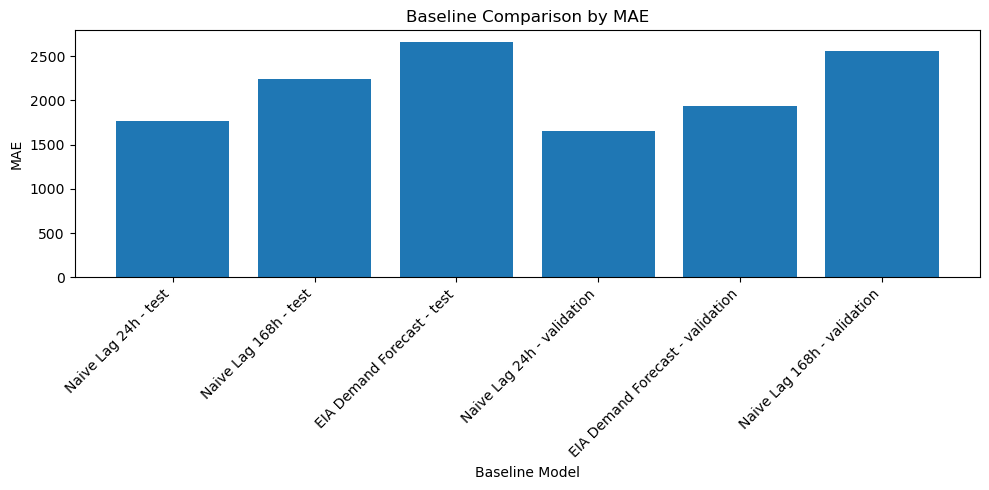

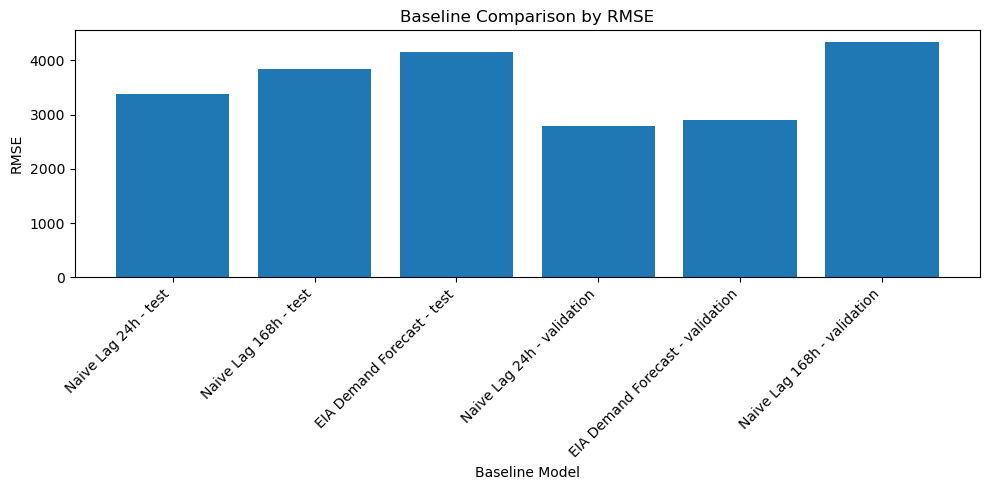

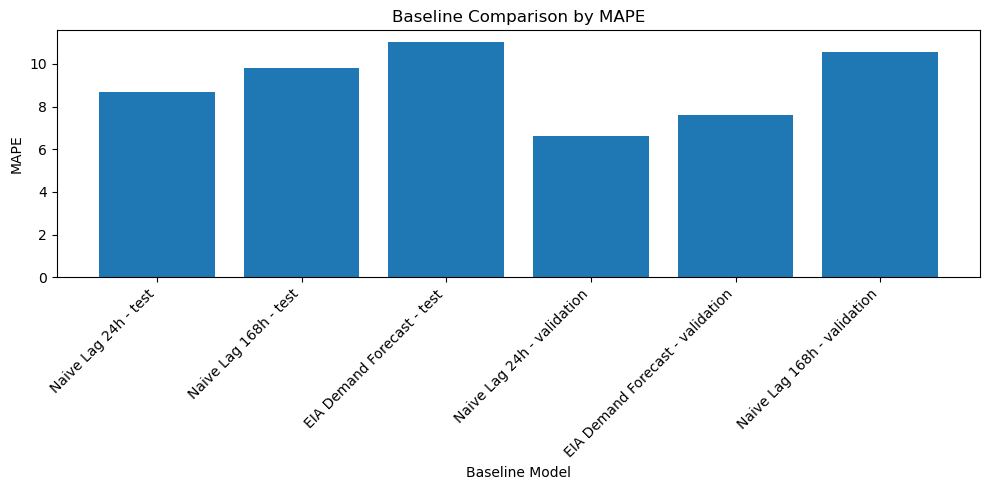

In [75]:
for metric in ["MAE", "RMSE", "MAPE"]:
    temp = baseline_results_df.copy()

    plt.figure(figsize=(10, 5))
    
    labels = temp["model"] + " - " + temp["split"]
    plt.bar(labels, temp[metric])
    
    plt.xlabel("Baseline Model")
    plt.ylabel(metric)
    plt.title(f"Baseline Comparison by {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Multiple Linear Regression and LASSO Regression

In [76]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

valid_pred_linear = linear_model.predict(X_valid)
test_pred_linear = linear_model.predict(X_test)

linear_valid_metrics = evaluate_regression(y_valid, valid_pred_linear)
linear_test_metrics = evaluate_regression(y_test, test_pred_linear)

linear_results_df = pd.DataFrame([
    {
        "model": "Multiple Linear Regression",
        "split": "validation",
        "n_rows": len(y_valid),
        **linear_valid_metrics
    },
    {
        "model": "Multiple Linear Regression",
        "split": "test",
        "n_rows": len(y_test),
        **linear_test_metrics
    }
])

linear_results_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
0,Multiple Linear Regression,validation,8784,2179.984321,2869.660933,8.04811,0.797911
1,Multiple Linear Regression,test,11759,2193.859085,2992.765803,8.84266,0.680139


## hyperparameter tuning (lambda/alpha)

In [85]:
alpha_grid = np.logspace(-4, 4, 200)

lasso_tuning_results = []

for alpha in alpha_grid:
    lasso_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])

    lasso_model.fit(X_train, y_train)

    valid_pred = lasso_model.predict(X_valid)
    metrics = evaluate_regression(y_valid, valid_pred)

    coef = lasso_model.named_steps["model"].coef_
    n_nonzero_coef = np.sum(coef != 0)
    n_zero_coef = np.sum(coef == 0)

    lasso_tuning_results.append({
        "alpha": alpha,
        "n_nonzero_coef": n_nonzero_coef,
        "n_zero_coef": n_zero_coef,
        **metrics
    })

lasso_tuning_results_df = pd.DataFrame(lasso_tuning_results)
lasso_tuning_results_df.sort_values("RMSE").head(10)

c:\Users\surya\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.682e+12, tolerance: 5.021e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\surya\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.682e+12, tolerance: 5.021e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\surya\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.682e+12, toleranc

,alpha,n_nonzero_coef,n_zero_coef,MAE,RMSE,MAPE,R2
113,3.489101,25,2,2176.647700,2866.486240,8.047564,0.798358
114,3.827494,25,2,2176.508056,2866.546021,8.048827,0.798349
112,3.180626,26,1,2176.822289,2866.600794,8.047092,0.798342
115,4.198707,23,4,2176.426959,2866.716298,8.050235,0.798326
111,2.899423,26,1,2177.002360,2866.750225,8.046803,0.798321
116,4.605922,23,4,2176.316355,2866.871049,8.051304,0.798304
110,2.643081,26,1,2177.178847,2866.906892,8.046624,0.798299
117,5.052631,23,4,2176.203510,2867.047781,8.052504,0.798279
109,2.409404,26,1,2177.351147,2867.066760,8.046529,0.798276
108,2.196385,26,1,2177.524691,2867.226617,8.046495,0.798254


In [86]:
best_lasso_row = lasso_tuning_results_df.sort_values("RMSE").iloc[0]
best_alpha = best_lasso_row["alpha"]

print("Best alpha:", best_alpha)
display(best_lasso_row)

Best alpha: 3.489101213406774


alpha                3.489101
n_nonzero_coef      25.000000
n_zero_coef          2.000000
MAE               2176.647700
RMSE              2866.486240
MAPE                 8.047564
R2                   0.798358
Name: 113, dtype: float64

In [87]:
best_lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=best_alpha, max_iter=10000, random_state=42))
])

best_lasso_model.fit(X_train, y_train)

valid_pred_lasso = best_lasso_model.predict(X_valid)
test_pred_lasso = best_lasso_model.predict(X_test)

lasso_valid_metrics = evaluate_regression(y_valid, valid_pred_lasso)
lasso_test_metrics = evaluate_regression(y_test, test_pred_lasso)

lasso_results_df = pd.DataFrame([
    {
        "model": f"LASSO Regression alpha={best_alpha:.6g}",
        "split": "validation",
        "n_rows": len(y_valid),
        **lasso_valid_metrics
    },
    {
        "model": f"LASSO Regression alpha={best_alpha:.6g}",
        "split": "test",
        "n_rows": len(y_test),
        **lasso_test_metrics
    }
])

lasso_results_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
0,LASSO Regression alpha=3.4891,validation,8784,2176.647700,2866.486240,8.047564,0.798358
1,LASSO Regression alpha=3.4891,test,11759,2188.488477,2986.551478,8.835745,0.681466


In [88]:
all_results_df = pd.concat(
    [
        baseline_results_df,
        linear_results_df,
        lasso_results_df
    ],
    ignore_index=True
)

all_results_df = all_results_df[
    ["model", "split", "n_rows", "MAE", "RMSE", "MAPE", "R2"]
].sort_values(["split", "RMSE"])

all_results_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
9,LASSO Regression alpha=3.4891,test,11759,2188.488477,2986.551478,8.835745,0.681466
7,Multiple Linear Regression,test,11759,2193.859085,2992.765803,8.842660,0.680139
0,Naive Lag 24h,test,11759,1768.349009,3372.500849,8.692171,0.593819
1,Naive Lag 168h,test,11759,2240.259801,3844.403011,9.822217,0.472195
2,EIA Demand Forecast,test,11759,2658.461859,4153.280552,11.025787,0.383975
3,Naive Lag 24h,validation,8784,1653.641166,2782.622101,6.604661,0.809984
8,LASSO Regression alpha=3.4891,validation,8784,2176.647700,2866.486240,8.047564,0.798358
6,Multiple Linear Regression,validation,8784,2179.984321,2869.660933,8.048110,0.797911
4,EIA Demand Forecast,validation,8784,1935.173042,2902.855400,7.596954,0.793209
5,Naive Lag 168h,validation,8784,2553.267532,4336.636310,10.567133,0.538483


## LASSO Coefficient

In [89]:
lasso_coef = best_lasso_model.named_steps["model"].coef_

lasso_coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lasso_coef,
    "abs_coefficient": np.abs(lasso_coef)
})

lasso_coef_df = lasso_coef_df.sort_values("abs_coefficient", ascending=False)

print("Total features:", len(feature_cols))
print("Non-zero coefficients:", (lasso_coef_df["coefficient"] != 0).sum())
print("Zero coefficients:", (lasso_coef_df["coefficient"] == 0).sum())

lasso_coef_df

Total features: 27
Non-zero coefficients: 25
Zero coefficients: 2


,feature,coefficient,abs_coefficient
23,rolling_mean_24h,6285.161765,6285.161765
25,rolling_std_24h,-5637.899850,5637.899850
7,hour_sin,-3173.967889,3173.967889
26,rolling_std_168h,1165.982181,1165.982181
5,heating_degree,1025.836225,1025.836225
4,cooling_degree,1012.354402,1012.354402
15,is_weekend,-684.046502,684.046502
10,day_of_week_cos,496.528055,496.528055
24,rolling_mean_168h,471.275981,471.275981
12,month_cos,-398.694421,398.694421


## Save results

In [90]:
linear_results_df.to_csv(
    f"{OUTPUT_DIR}/linear_regression_results.csv",
    index=False
)

lasso_results_df.to_csv(
    f"{OUTPUT_DIR}/lasso_regression_results.csv",
    index=False
)

lasso_tuning_results_df.to_csv(
    f"{OUTPUT_DIR}/lasso_tuning_results.csv",
    index=False
)

lasso_coef_df.to_csv(
    f"{OUTPUT_DIR}/lasso_coefficients.csv",
    index=False
)

all_results_df.to_csv(
    f"{OUTPUT_DIR}/all_results_until_lasso.csv",
    index=False
)

print("Saved linear and LASSO outputs.")

Saved linear and LASSO outputs.


In [91]:
linear_model_path = f"{MODEL_OUTPUT_DIR}/multiple_linear_regression_pipeline.joblib"

joblib.dump(linear_model, linear_model_path)

print("Saved Multiple Linear Regression pipeline to:")
print(linear_model_path)

Saved Multiple Linear Regression pipeline to:
modeling_outputs/saved_models/multiple_linear_regression_pipeline.joblib


In [92]:
linear_model_metadata = {
    "model_name": "Multiple Linear Regression",
    "model_type": "Pipeline(StandardScaler + LinearRegression)",
    "target_column_train": "target_region_demand_mw",
    "target_column_eval": "region_demand_mw",
    "feature_columns": feature_cols,
    "prediction_unit": "MW",
    "notes": "Input features are standardized inside the saved pipeline. Target is not scaled."
}

metadata_path = f"{MODEL_OUTPUT_DIR}/multiple_linear_regression_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(linear_model_metadata, f, indent=4)

print("Saved metadata to:")
print(metadata_path)

Saved metadata to:
modeling_outputs/saved_models/multiple_linear_regression_metadata.json


# XGBoost

In [96]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

valid_pred_xgb = xgb_model.predict(X_valid)
test_pred_xgb = xgb_model.predict(X_test)

xgb_valid_metrics = evaluate_regression(y_valid, valid_pred_xgb)
xgb_test_metrics = evaluate_regression(y_test, test_pred_xgb)

xgb_results_df = pd.DataFrame([
    {
        "model": "XGBoost Regressor",
        "split": "validation",
        "n_rows": len(y_valid),
        **xgb_valid_metrics
    },
    {
        "model": "XGBoost Regressor",
        "split": "test",
        "n_rows": len(y_test),
        **xgb_test_metrics
    }
])

xgb_results_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
0,XGBoost Regressor,validation,8784,1389.837091,7199.187619,5.868554,-0.271887
1,XGBoost Regressor,test,11759,1366.037975,6161.807803,7.634681,-0.355914


## Hyperparameter tuning

In [109]:
xgb_search_space = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_lambda": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1],
}

all_param_combinations = [
    dict(zip(xgb_search_space.keys(), values))
    for values in product(*xgb_search_space.values())
]

RANDOM_STATE = 42
N_TRIALS = 32

random.seed(RANDOM_STATE)

xgb_param_grid = random.sample(
    all_param_combinations,
    min(N_TRIALS, len(all_param_combinations))
)

print("Total possible combinations:", len(all_param_combinations))
print("Number of sampled tuning trials:", len(xgb_param_grid))

xgb_tuning_results = []

start_time = time.time()

for i, params in enumerate(xgb_param_grid, start=1):
    print(f"Training XGBoost config {i}/{len(xgb_param_grid)}:", params)

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    valid_pred = model.predict(X_valid)
    metrics = evaluate_regression(y_valid, valid_pred)

    xgb_tuning_results.append({
        "config_id": i,
        **params,
        **metrics
    })

    print(
        f"RMSE: {metrics['RMSE']:.4f} | "
        f"MAE: {metrics['MAE']:.4f} | "
        f"MAPE: {metrics['MAPE']:.4f}"
    )
    print("-" * 80)

elapsed_time = time.time() - start_time

xgb_tuning_results_df = pd.DataFrame(xgb_tuning_results)

print(f"Total tuning time: {elapsed_time / 60:.2f} minutes")

xgb_tuning_results_df.sort_values("RMSE").head(10)

Total possible combinations: 8748
Number of sampled tuning trials: 32
Training XGBoost config 1/32: {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 10, 'reg_alpha': 0}
RMSE: 5777.5324 | MAE: 1249.8061 | MAPE: 5.4737
--------------------------------------------------------------------------------
Training XGBoost config 2/32: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1}
RMSE: 2452.5054 | MAE: 1187.7151 | MAPE: 5.9260
--------------------------------------------------------------------------------
Training XGBoost config 3/32: {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_lambda': 10, 'reg_alpha': 0}
RMSE: 5227.5856 | MAE: 1245.5840 | MAPE: 5.3487
-------------------------------------------------

,config_id,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,MAE,RMSE,MAPE,R2
3,4,500,0.03,3,5,0.9,0.9,10,0.1,993.950079,2024.545021,4.511594,0.899414
21,22,300,0.01,3,5,0.8,1.0,10,0.1,1182.129151,2189.246544,6.146716,0.882383
16,17,500,0.01,4,5,0.8,0.9,10,1.0,1054.674067,2350.498220,5.189128,0.864418
1,2,300,0.01,4,10,0.8,0.8,5,0.1,1187.715130,2452.505418,5.926026,0.852395
15,16,300,0.01,4,10,0.9,0.8,1,1.0,1221.151495,2500.929518,6.036239,0.846508
31,32,800,0.01,4,5,1.0,0.9,5,1.0,1064.723873,2723.074527,5.052454,0.818030
17,18,800,0.03,3,1,1.0,0.9,10,0.0,1088.668248,2793.203447,4.460831,0.808536
7,8,300,0.03,4,10,0.9,1.0,1,1.0,1104.399529,2911.861613,5.216461,0.791924
8,9,800,0.03,3,5,0.9,0.8,1,0.0,1135.738203,2985.153829,4.975663,0.781317
23,24,800,0.03,3,5,0.9,0.9,5,0.0,1165.785318,2988.585726,5.147119,0.780814


In [110]:
best_xgb_row = xgb_tuning_results_df.sort_values("RMSE").iloc[0]

best_xgb_params = {
    "n_estimators": int(best_xgb_row["n_estimators"]),
    "learning_rate": float(best_xgb_row["learning_rate"]),
    "max_depth": int(best_xgb_row["max_depth"]),
    "min_child_weight": float(best_xgb_row["min_child_weight"]),
    "subsample": float(best_xgb_row["subsample"]),
    "colsample_bytree": float(best_xgb_row["colsample_bytree"]),
    "reg_lambda": float(best_xgb_row["reg_lambda"]),
    "reg_alpha": float(best_xgb_row["reg_alpha"]),
}

print("Best XGBoost parameters:")
print(best_xgb_params)

display(best_xgb_row)

Best XGBoost parameters:
{'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5.0, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 0.1}


config_id              4.000000
n_estimators         500.000000
learning_rate          0.030000
max_depth              3.000000
min_child_weight       5.000000
subsample              0.900000
colsample_bytree       0.900000
reg_lambda            10.000000
reg_alpha              0.100000
MAE                  993.950079
RMSE                2024.545021
MAPE                   4.511594
R2                     0.899414
Name: 3, dtype: float64

In [111]:
best_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_xgb_params
)

best_xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

valid_pred_best_xgb = best_xgb_model.predict(X_valid)
test_pred_best_xgb = best_xgb_model.predict(X_test)

best_xgb_valid_metrics = evaluate_regression(y_valid, valid_pred_best_xgb)
best_xgb_test_metrics = evaluate_regression(y_test, test_pred_best_xgb)

best_xgb_results_df = pd.DataFrame([
    {
        "model": "XGBoost Regressor Tuned",
        "split": "validation",
        "n_rows": len(y_valid),
        **best_xgb_valid_metrics
    },
    {
        "model": "XGBoost Regressor Tuned",
        "split": "test",
        "n_rows": len(y_test),
        **best_xgb_test_metrics
    }
])

best_xgb_results_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
0,XGBoost Regressor Tuned,validation,8784,993.950079,2024.545021,4.511594,0.899414
1,XGBoost Regressor Tuned,test,11759,1033.408053,2194.336483,5.179278,0.828042


In [112]:
all_results_final_df = pd.concat(
    [
        all_results_df,
        best_xgb_results_df
    ],
    ignore_index=True
)

all_results_final_df = all_results_final_df[
    ["model", "split", "n_rows", "MAE", "RMSE", "MAPE", "R2"]
].sort_values(["split", "RMSE"])

all_results_final_df

,model,split,n_rows,MAE,RMSE,MAPE,R2
11,XGBoost Regressor Tuned,test,11759,1033.408053,2194.336483,5.179278,0.828042
0,LASSO Regression alpha=3.4891,test,11759,2188.488477,2986.551478,8.835745,0.681466
1,Multiple Linear Regression,test,11759,2193.859085,2992.765803,8.842660,0.680139
2,Naive Lag 24h,test,11759,1768.349009,3372.500849,8.692171,0.593819
3,Naive Lag 168h,test,11759,2240.259801,3844.403011,9.822217,0.472195
4,EIA Demand Forecast,test,11759,2658.461859,4153.280552,11.025787,0.383975
10,XGBoost Regressor Tuned,validation,8784,993.950079,2024.545021,4.511594,0.899414
5,Naive Lag 24h,validation,8784,1653.641166,2782.622101,6.604661,0.809984
6,LASSO Regression alpha=3.4891,validation,8784,2176.647700,2866.486240,8.047564,0.798358
7,Multiple Linear Regression,validation,8784,2179.984321,2869.660933,8.048110,0.797911


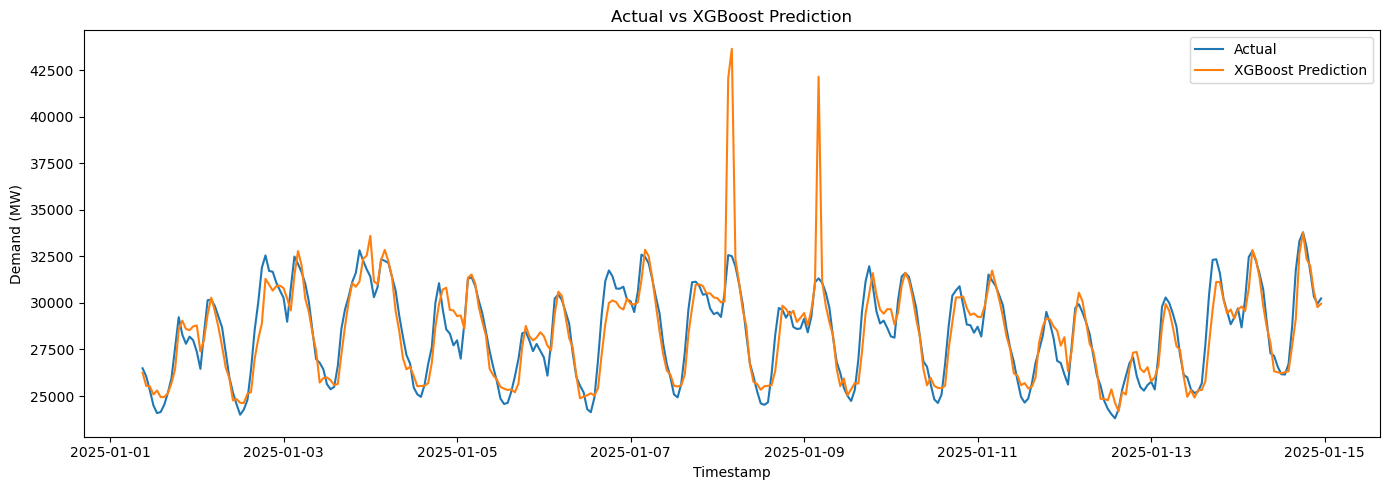

In [113]:
plot_df = test_model_df.copy()
plot_df["xgb_prediction"] = test_pred_best_xgb

plot_start = "2025-01-01"
plot_end = "2025-01-15"

plot_sample = plot_df[
    (plot_df["timestamp_utc"] >= plot_start) &
    (plot_df["timestamp_utc"] < plot_end)
].copy()

plt.figure(figsize=(14, 5))
plt.plot(plot_sample["timestamp_utc"], plot_sample["region_demand_mw"], label="Actual")
plt.plot(plot_sample["timestamp_utc"], plot_sample["xgb_prediction"], label="XGBoost Prediction")
plt.xlabel("Timestamp")
plt.ylabel("Demand (MW)")
plt.title("Actual vs XGBoost Prediction")
plt.legend()
plt.tight_layout()
plt.show()

## feature importance

In [114]:
xgb_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importance_df

,feature,importance
14,day_of_year_cos,0.104207
3,precipitation,0.095670
23,rolling_mean_24h,0.093886
5,heating_degree,0.073168
9,day_of_week_sin,0.063629
12,month_cos,0.060438
20,lag_1h,0.057562
1,relative_humidity_2m,0.053589
2,wind_speed_10m,0.052270
21,lag_24h,0.045431


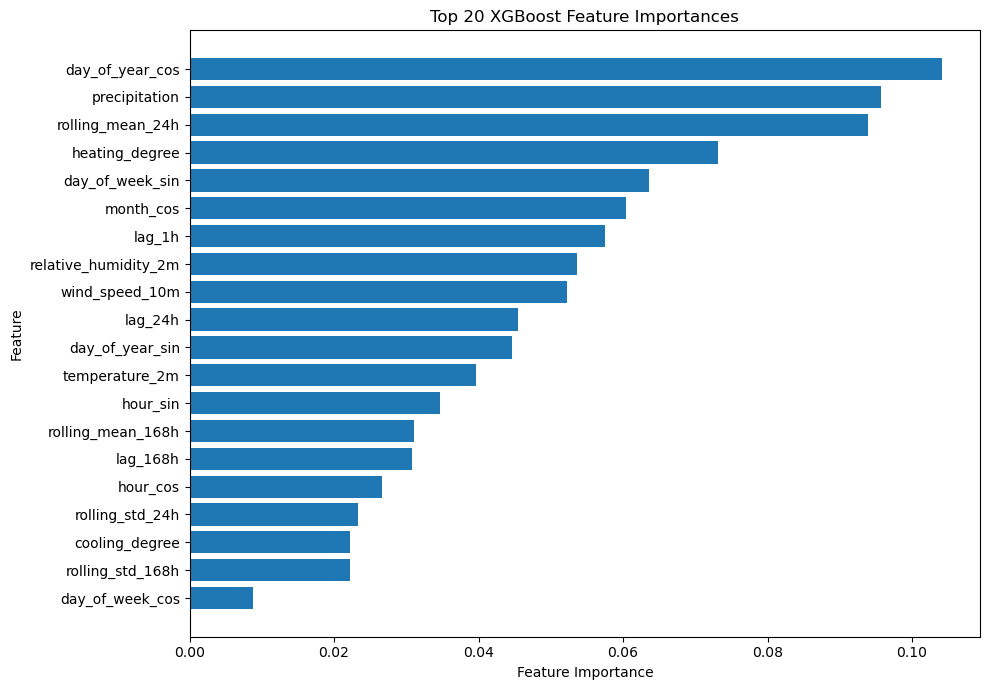

In [115]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10, 7))
plt.barh(
    xgb_importance_df.head(top_n)["feature"][::-1],
    xgb_importance_df.head(top_n)["importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## Save results

In [116]:
xgb_model_path = f"{MODEL_OUTPUT_DIR}/xgboost_regressor_tuned.joblib"

joblib.dump(best_xgb_model, xgb_model_path)

print("Saved XGBoost model to:")
print(xgb_model_path)

Saved XGBoost model to:
modeling_outputs/saved_models/xgboost_regressor_tuned.joblib


In [117]:
xgb_metadata = {
    "model_name": "XGBoost Regressor Tuned",
    "model_type": "XGBRegressor",
    "target_column_train": "target_region_demand_mw",
    "target_column_eval": "region_demand_mw",
    "feature_columns": feature_cols,
    "best_params": best_xgb_params,
    "prediction_unit": "MW",
    "notes": "XGBoost model trained without feature standardization. Test set was not used for tuning."
}

xgb_metadata_path = f"{MODEL_OUTPUT_DIR}/xgboost_regressor_tuned_metadata.json"

with open(xgb_metadata_path, "w", encoding="utf-8") as f:
    json.dump(xgb_metadata, f, indent=4)

print("Saved XGBoost metadata to:")
print(xgb_metadata_path)

Saved XGBoost metadata to:
modeling_outputs/saved_models/xgboost_regressor_tuned_metadata.json


In [118]:
xgb_tuning_results_df.to_csv(
    f"{OUTPUT_DIR}/xgboost_tuning_results.csv",
    index=False
)

xgb_importance_df.to_csv(
    f"{OUTPUT_DIR}/xgboost_feature_importance.csv",
    index=False
)

all_results_final_df.to_csv(
    f"{OUTPUT_DIR}/all_results_until_xgboost.csv",
    index=False
)

print("Saved XGBoost outputs.")

Saved XGBoost outputs.


# TFT

In [119]:
!pip install pytorch-forecasting lightning torch

   ---------------------------------------- 0.0/848.6 kB ? eta -:--:--
   ---------------------------------------- 848.6/848.6 kB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   -- ------------------------------------- 6.8/123.0 MB 31.9 MB/s eta 0:00:04
   ---- ----------------------------------- 14.9/123.0 MB 35.7 MB/s eta 0:00:04
   ------- -------------------------------- 21.8/123.0 MB 34.2 MB/s eta 0:00:03
   --------- ------------------------------ 29.4/123.0 MB 34.3 MB/s eta 0:00:03
   ------------ --------------------------- 37.5/123.0 MB 35.1 MB/s eta 0:00:03
   -------------- ------------------------- 45.4/123.0 MB 35.8 MB/s eta 0:00:03
   ---------------- ----------------------- 51.9/123.0 MB 34.9 MB/s eta 0:00:03
   ------------------- -------------------- 61.3/123.0 MB 35.9 MB/s eta 0:00:02
   ---------------------- ----------------- 69.7/123.0 MB 36.6 MB/s eta 0:00:02
   ------------------------- -------------- 78.9/123.0 MB 37.

In [120]:
import os
import json
import numpy as np
import pandas as pd
import torch

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE
from pytorch_forecasting.data import GroupNormalizer

## prepare dataframe

In [121]:
df_tft = df_model.copy()

df_tft["timestamp_utc"] = pd.to_datetime(df_tft["timestamp_utc"], utc=True)
df_tft["data_date"] = pd.to_datetime(df_tft["data_date"])

df_tft = df_tft.sort_values("timestamp_utc").reset_index(drop=True)

# Continuous hourly time index
df_tft["time_idx"] = (
    (df_tft["timestamp_utc"] - df_tft["timestamp_utc"].min())
    .dt.total_seconds() // 3600
).astype(int)

# Group identifier
df_tft["Region"] = df_tft["Region"].astype(str)

# TFT target
df_tft["model_target_mw"] = np.where(
    df_tft["data_date"] < pd.Timestamp("2024-01-01"),
    df_tft["target_region_demand_mw"],
    df_tft["region_demand_mw"]
)

# Drop rows without target for TFT dataset construction
df_tft = df_tft.dropna(subset=["model_target_mw"]).copy()

print("TFT dataset shape:", df_tft.shape)
print("Missing model target:", df_tft["model_target_mw"].isna().sum())
print("Time index range:", df_tft["time_idx"].min(), "to", df_tft["time_idx"].max())

df_tft.head()

TFT dataset shape: (95088, 62)
Missing model target: 0
Time index range: 0 to 95087


,timestamp_utc,Region,data_date,region_demand_mw,region_demand_forecast_mw,num_ba,num_rows,num_available_ba,num_missing_ba,year,...,temp_squared,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_std_168h,time_idx,model_target_mw
0,2015-07-01 08:00:00+00:00,CAL,2015-07-01,38210.0,35264.0,5,5,5,0,2015,...,552.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,38210.0
1,2015-07-01 09:00:00+00:00,CAL,2015-07-01,35171.0,32894.0,5,5,5,0,2015,...,510.76,38210.0,NaN,NaN,NaN,NaN,NaN,NaN,1,35171.0
2,2015-07-01 10:00:00+00:00,CAL,2015-07-01,33243.0,31360.0,5,5,5,0,2015,...,470.89,35171.0,NaN,NaN,NaN,NaN,NaN,NaN,2,33243.0
3,2015-07-01 11:00:00+00:00,CAL,2015-07-01,31955.0,30579.0,5,5,5,0,2015,...,453.69,33243.0,NaN,NaN,NaN,NaN,NaN,NaN,3,31955.0
4,2015-07-01 12:00:00+00:00,CAL,2015-07-01,31199.0,30723.0,5,5,5,0,2015,...,449.44,31955.0,NaN,NaN,NaN,NaN,NaN,NaN,4,31199.0


## define split boundaries

In [122]:
train_end_date = pd.Timestamp("2024-01-01")
valid_end_date = pd.Timestamp("2025-01-01")
test_end_date = pd.Timestamp("2026-05-07")

train_max_time_idx = df_tft.loc[
    df_tft["data_date"] < train_end_date,
    "time_idx"
].max()

valid_start_time_idx = df_tft.loc[
    df_tft["data_date"] >= train_end_date,
    "time_idx"
].min()

test_start_time_idx = df_tft.loc[
    df_tft["data_date"] >= valid_end_date,
    "time_idx"
].min()

print("Train max time_idx:", train_max_time_idx)
print("Validation start time_idx:", valid_start_time_idx)
print("Test start time_idx:", test_start_time_idx)

Train max time_idx: 74544
Validation start time_idx: 74545
Test start time_idx: 83329


## define features

In [123]:
max_encoder_length = 168
max_prediction_length = 1

known_reals = [
    # Time
    "time_idx",

    # Weather
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "cooling_degree",
    "heating_degree",
    "temp_squared",

    # Calendar and seasonality
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",

    # Holiday
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "is_holiday_period",
]

known_reals = [col for col in known_reals if col in df_tft.columns]

static_categoricals = ["Region"]

print("Known real features:", len(known_reals))
known_reals

Known real features: 21


['time_idx',
 'temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'precipitation',
 'cooling_degree',
 'heating_degree',
 'temp_squared',
 'hour_sin',
 'hour_cos',
 'day_of_week_sin',
 'day_of_week_cos',
 'month_sin',
 'month_cos',
 'day_of_year_sin',
 'day_of_year_cos',
 'is_weekend',
 'is_holiday',
 'is_day_before_holiday',
 'is_day_after_holiday',
 'is_holiday_period']

## create TimeSeriesDataSet

In [124]:
training = TimeSeriesDataSet(
    df_tft[df_tft["data_date"] < train_end_date],
    time_idx="time_idx",
    target="model_target_mw",
    group_ids=["Region"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=static_categoricals,

    time_varying_known_reals=known_reals,

    time_varying_unknown_reals=[
        "model_target_mw"
    ],

    target_normalizer=GroupNormalizer(
        groups=["Region"],
        transformation="softplus"
    ),

    allow_missing_timesteps=True,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_tft[df_tft["data_date"] < valid_end_date],
    min_prediction_idx=valid_start_time_idx,
    stop_randomization=True
)

test = TimeSeriesDataSet.from_dataset(
    training,
    df_tft[df_tft["data_date"] < test_end_date],
    min_prediction_idx=test_start_time_idx,
    stop_randomization=True
)

batch_size = 128

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=0
)

valid_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0
)

test_dataloader = test.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0
)

print("Training batches:", len(train_dataloader))
print("Validation batches:", len(valid_dataloader))
print("Test batches:", len(test_dataloader))

Training batches: 581
Validation batches: 69
Test batches: 92


## initial model

In [125]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=RMSE(),
    optimizer="adam",
    reduce_on_plateau_patience=3,
)

print(f"Number of parameters: {tft.size() / 1e3:.1f}k")

Number of parameters: 47.7k


c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


## training

In [ ]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=5,
    verbose=True,
    mode="min"
)

lr_logger = LearningRateMonitor()

logger = CSVLogger(
    save_dir="modeling_outputs/tft_logs",
    name="tft_one_step"
)

trainer = Trainer(
    max_epochs=20,
    accelerator="auto",
    devices="auto",
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, lr_logger],
    logger=logger,
    enable_model_summary=True,
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=valid_dataloader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ RMSE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    416 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 16.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 15.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 47.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 47.7 K                                                                                               
Total estimated model params size (MB): 0.191                                                                      
Modules in train mode: 860                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

c:\Users\surya\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

In [ ]:
valid_pred_tft = tft.predict(valid_dataloader)
test_pred_tft = tft.predict(test_dataloader)

print("Validation prediction shape:", valid_pred_tft.shape)
print("Test prediction shape:", test_pred_tft.shape)

In [ ]:
def extract_actuals_from_dataloader(dataloader):
    actuals = []

    for x, y in dataloader:
        if isinstance(y, tuple):
            y = y[0]
        actuals.append(y.detach().cpu())

    return torch.cat(actuals, dim=0)


valid_actual_tft = extract_actuals_from_dataloader(valid_dataloader)
test_actual_tft = extract_actuals_from_dataloader(test_dataloader)

valid_pred_tft_np = valid_pred_tft.detach().cpu().numpy().reshape(-1)
test_pred_tft_np = test_pred_tft.detach().cpu().numpy().reshape(-1)

valid_actual_tft_np = valid_actual_tft.detach().cpu().numpy().reshape(-1)
test_actual_tft_np = test_actual_tft.detach().cpu().numpy().reshape(-1)

print("Validation actual:", valid_actual_tft_np.shape)
print("Validation pred:", valid_pred_tft_np.shape)
print("Test actual:", test_actual_tft_np.shape)
print("Test pred:", test_pred_tft_np.shape)

## evaluate

In [ ]:
tft_valid_metrics = evaluate_regression(
    valid_actual_tft_np,
    valid_pred_tft_np
)

tft_test_metrics = evaluate_regression(
    test_actual_tft_np,
    test_pred_tft_np
)

tft_results_df = pd.DataFrame([
    {
        "model": "Temporal Fusion Transformer One-Step",
        "split": "validation",
        "n_rows": len(valid_actual_tft_np),
        **tft_valid_metrics
    },
    {
        "model": "Temporal Fusion Transformer One-Step",
        "split": "test",
        "n_rows": len(test_actual_tft_np),
        **tft_test_metrics
    }
])

tft_results_df

In [ ]:
all_results_with_tft_df = pd.concat(
    [
        all_results_final_df,
        tft_results_df
    ],
    ignore_index=True
)

all_results_with_tft_df = all_results_with_tft_df[
    ["model", "split", "n_rows", "MAE", "RMSE", "MAPE", "R2"]
].sort_values(["split", "RMSE"])

all_results_with_tft_df

In [ ]:
tft_plot_df = pd.DataFrame({
    "actual": test_actual_tft_np,
    "prediction": test_pred_tft_np
})

plot_n = min(24 * 14, len(tft_plot_df))

plt.figure(figsize=(14, 5))
plt.plot(tft_plot_df["actual"].iloc[:plot_n].values, label="Actual")
plt.plot(tft_plot_df["prediction"].iloc[:plot_n].values, label="TFT Prediction")
plt.xlabel("Prediction Step")
plt.ylabel("Demand (MW)")
plt.title("Actual vs TFT One-Step Prediction")
plt.legend()
plt.tight_layout()
plt.show()

## Save results

In [ ]:
TFT_OUTPUT_DIR = "modeling_outputs/saved_models"
os.makedirs(TFT_OUTPUT_DIR, exist_ok=True)

tft_model_path = f"{TFT_OUTPUT_DIR}/temporal_fusion_transformer_one_step.ckpt"

trainer.save_checkpoint(tft_model_path)

tft_results_df.to_csv(
    "modeling_outputs/tft_one_step_results.csv",
    index=False
)

all_results_with_tft_df.to_csv(
    "modeling_outputs/all_results_with_tft.csv",
    index=False
)

tft_metadata = {
    "model_name": "Temporal Fusion Transformer One-Step",
    "model_type": "TemporalFusionTransformer",
    "encoder_length_hours": max_encoder_length,
    "prediction_length_hours": max_prediction_length,
    "target_column": "model_target_mw",
    "train_target_source": "target_region_demand_mw",
    "validation_test_target_source": "region_demand_mw",
    "known_real_features": known_reals,
    "static_categoricals": static_categoricals,
    "prediction_unit": "MW",
    "notes": "TFT uses a 168-hour encoder window and predicts one hour ahead for comparability with tabular models."
}

with open(f"{TFT_OUTPUT_DIR}/temporal_fusion_transformer_one_step_metadata.json", "w", encoding="utf-8") as f:
    json.dump(tft_metadata, f, indent=4)

print("Saved TFT checkpoint to:", tft_model_path)